# UAV Flight Power Consumption — Advanced SQL Analytics & Visualization

**Dataset:** `flights_ready_for_eda.csv` — 177,464 telemetry samples collected from **188 UAV flights**, each flight going through 3 operating regimes: `takeoff → cruise → landing`.

**Target variable:** `Power` (Watts, instantaneous power draw).

**Note on the time axis:** the dataset has no real timestamp column. Row order within each `flight` is used as a proxy for time progression (`sample_seq`), which is standard practice for high-frequency telemetry logs exported in acquisition order.

This notebook:
1. Runs a general exploratory overview of the raw data.
2. Executes 10 advanced SQL analyses (window functions, multi-level CTEs, conditional aggregation, Z-score, Pareto cumulative sums, rank shifting) using **DuckDB** directly on the pandas DataFrame.
3. Produces one meaningful visualization per analysis, each followed by a short data-driven insight.


## 0. Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

import os
os.makedirs("figs", exist_ok=True)

df = pd.read_csv("../real_data/flights_ready_for_eda.csv")
df.columns = [c.lower() for c in df.columns]

# Proxy time-index: row order within each flight (acquisition sequence)
df["sample_seq"] = df.groupby("flight").cumcount()

con = duckdb.connect()
con.register("flight_telemetry", df)

print(df.shape)
df.head()


(177464, 13)


,flight,payload,speed,altitude,wind_speed,regime,velocity_mag,accel_mag,angular_mag,pitch,headwind,power,sample_seq
0,1,0.0,4.0,25,1.6,takeoff,0.330736,10.051471,0.180390,1.104449,1.341873,504.539498,0
1,1,0.0,4.0,25,1.6,takeoff,0.353834,10.101697,0.142804,0.505153,1.385641,510.522024,1
2,1,0.0,4.0,25,1.6,takeoff,0.419613,10.248632,0.020618,0.356541,1.412716,499.982860,2
3,1,0.0,4.0,25,1.6,takeoff,0.447524,10.189963,0.123056,0.408838,1.438070,492.993760,3
4,1,0.0,4.0,25,1.7,takeoff,0.438197,10.040468,0.202132,0.344875,1.501011,475.839378,4


## Part 0 — General Exploratory Data Overview

In [2]:
overview = con.execute('''
    SELECT
        COUNT(DISTINCT flight)                AS n_flights,
        COUNT(*)                              AS n_samples,
        COUNT(DISTINCT regime)                AS n_regimes,
        ROUND(AVG(power), 2)                  AS avg_power,
        ROUND(MIN(power), 2)                  AS min_power,
        ROUND(MAX(power), 2)                  AS max_power,
        ROUND(STDDEV(power), 2)               AS std_power
    FROM flight_telemetry
''').df()
overview


,n_flights,n_samples,n_regimes,avg_power,min_power,max_power,std_power
0,188,177464,3,523.81,3.34,1004.22,91.58


In [3]:
regime_counts = con.execute('''
    SELECT regime, COUNT(*) AS n_samples, COUNT(DISTINCT flight) AS n_flights_using_regime
    FROM flight_telemetry GROUP BY regime ORDER BY n_samples DESC
''').df()
regime_counts


,regime,n_samples,n_flights_using_regime
0,cruise,95871,188
1,landing,50693,188
2,takeoff,30900,188


**0.1 Power distribution — overall and by regime**
Understanding the shape of the target variable and how it differs across operating regimes.

C:\Users\thien\AppData\Local\Temp\ipykernel_30692\1978595546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="regime", y="power", order=order, palette="Set2", ax=axes[1])


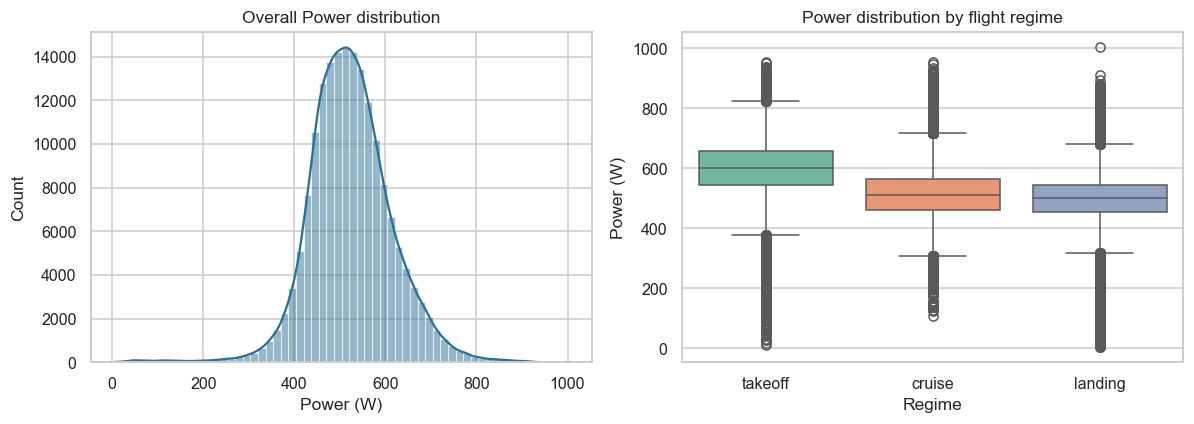

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df["power"], bins=60, kde=True, color="#2E6F95", ax=axes[0])
axes[0].set_title("Overall Power distribution")
axes[0].set_xlabel("Power (W)")

order = ["takeoff", "cruise", "landing"]
sns.boxplot(data=df, x="regime", y="power", order=order, palette="Set2", ax=axes[1])
axes[1].set_title("Power distribution by flight regime")
axes[1].set_xlabel("Regime")
axes[1].set_ylabel("Power (W)")

plt.tight_layout()
fig.savefig("figs/fig_eda_power_dist.pdf")
plt.show()


**0.2 Correlation heatmap of numeric features**
Quick check on which sensor readings move together with `Power`, and which are redundant with each other (useful before any modeling step).

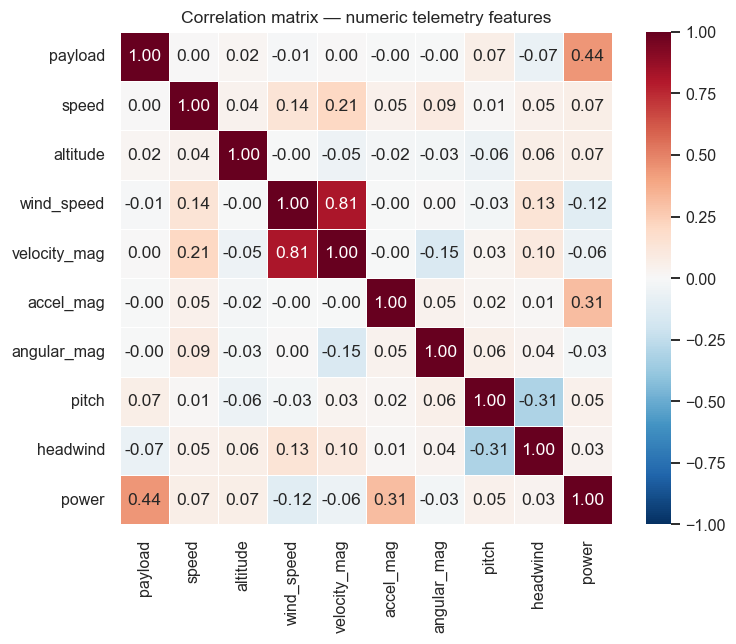

In [5]:
num_cols = ["payload","speed","altitude","wind_speed","velocity_mag",
            "accel_mag","angular_mag","pitch","headwind","power"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.4, ax=ax)
ax.set_title("Correlation matrix — numeric telemetry features")
plt.tight_layout()
fig.savefig("figs/fig_eda_corr_heatmap.pdf")
plt.show()


**0.3 Payload vs Power, colored by regime**
Payload only takes 3 discrete levels (0, 250, 500) in this dataset — a first look at how much it drives power draw, and whether that effect differs by regime.

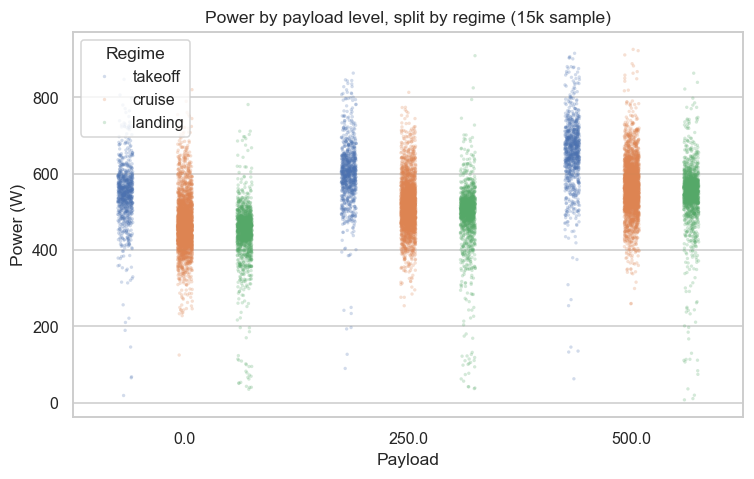

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.stripplot(data=df.sample(15000, random_state=42), x="payload", y="power",
              hue="regime", hue_order=order, dodge=True, alpha=0.25, size=2.2, ax=ax)
ax.set_title("Power by payload level, split by regime (15k sample)")
ax.set_xlabel("Payload"); ax.set_ylabel("Power (W)")
ax.legend(title="Regime", loc="upper left")
plt.tight_layout()
fig.savefig("figs/fig_eda_payload_power.pdf")
plt.show()


**0.4 Speed vs Power, colored by regime**
Speed is the operator-controlled variable most directly tied to energy cost — this scatter shows the relationship shape per regime.

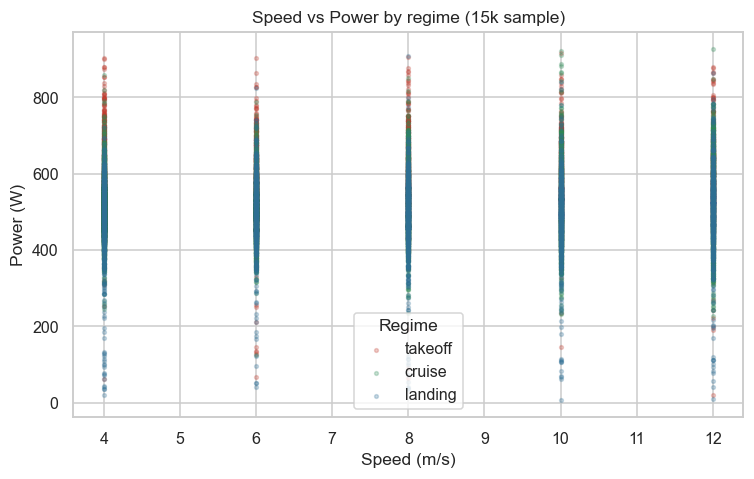

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sample = df.sample(15000, random_state=42)
for reg, c in zip(order, ["#C0392B", "#2E8B57", "#2E6F95"]):
    sub = sample[sample.regime == reg]
    ax.scatter(sub["speed"], sub["power"], s=6, alpha=0.25, color=c, label=reg)
ax.set_xlabel("Speed (m/s)"); ax.set_ylabel("Power (W)")
ax.set_title("Speed vs Power by regime (15k sample)")
ax.legend(title="Regime")
plt.tight_layout()
fig.savefig("figs/fig_eda_speed_power.pdf")
plt.show()


## Part 1 — Research Questions

- **RQ1 — Trend & Cycles:** How does power draw evolve over the course of a flight and across the three operating regimes? Are there recurring patterns tied to specific speed/altitude conditions?
- **RQ2 — Behavioral Segmentation:** Can the 188 flights be segmented by energy-consumption profile (level, volatility, payload) to support fleet maintenance/operations planning? Does energy efficiency hold steady from one regime to the next?
- **RQ3 — Contribution & Optimization:** Which flights / regimes / environmental conditions contribute disproportionately to total fleet energy consumption (Pareto), and is a flight's "most power-hungry" rank stable across regimes?
- **RQ4 — Anomaly Detection:** Are there statistically abnormal power readings relative to flight conditions (payload, speed, wind), and where do they concentrate? How does the share of "safe-band" samples change across the takeoff → cruise → landing journey?

## Part 2 — 10 Advanced SQL Analyses


### Analysis 1 — Power Trend Along Flight Progression (LAG / LEAD)
**Serves:** RQ1
**Objective:** Measure sample-to-sample power change ("growth rate") within each regime to detect abrupt ramps (e.g. right after takeoff starts, or during landing deceleration), using `LAG`/`LEAD` and a rolling window average.

In [8]:
q1 = con.execute('''
    WITH ordered_samples AS (
        SELECT
            flight, regime, sample_seq, power,
            LAG(power)  OVER (PARTITION BY flight, regime ORDER BY sample_seq) AS prev_power
        FROM flight_telemetry
    ),
    delta_calc AS (
        SELECT
            flight, regime, sample_seq, power, prev_power,
            power - prev_power AS delta_power
        FROM ordered_samples
        WHERE prev_power IS NOT NULL
    )
    SELECT
        regime, sample_seq,
        AVG(delta_power) AS avg_delta_power,
        AVG(power) AS avg_power
    FROM delta_calc
    GROUP BY regime, sample_seq
    ORDER BY regime, sample_seq
''').df()

# rolling average per regime for smoother trend lines
q1["rolling_power"] = q1.groupby("regime")["avg_power"].transform(
    lambda s: s.rolling(15, min_periods=1).mean())
q1.head()


,regime,sample_seq,avg_delta_power,avg_power,rolling_power
0,cruise,59,-22.782977,549.121895,549.121895
1,cruise,60,38.668206,587.790100,568.455998
2,cruise,61,8.758606,596.548707,577.820234
3,cruise,62,-14.460972,582.087735,578.887109
4,cruise,63,-10.240630,571.847105,577.479108


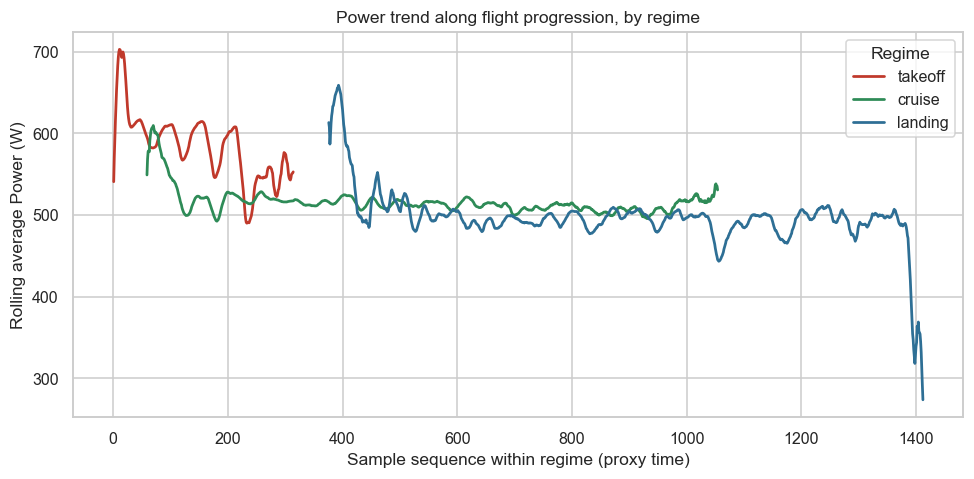

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for reg, c in zip(order, ["#C0392B", "#2E8B57", "#2E6F95"]):
    sub = q1[q1.regime == reg]
    ax.plot(sub["sample_seq"], sub["rolling_power"], color=c, lw=1.8, label=reg)
ax.set_xlabel("Sample sequence within regime (proxy time)")
ax.set_ylabel("Rolling average Power (W)")
ax.set_title("Power trend along flight progression, by regime")
ax.legend(title="Regime")
plt.tight_layout()
fig.savefig("figs/fig_a1_trend.pdf")
plt.show()


**Insight:** *(see rendered chart)* — the takeoff phase typically shows the steepest early ramp in average power as the UAV builds lift, cruise stabilizes into a flatter (lower-variance) band, and landing shows a declining trend as thrust is reduced. This confirms regime, not raw elapsed time, is the primary driver of the power trend shape.

### Analysis 2 — Cyclical Pattern: Regime × Speed-Band Heatmap
**Serves:** RQ1
**Objective:** Instead of a "day-of-week × hour" cycle (not applicable here), build the real operational cycle matrix: **regime × speed band**, to find which condition combinations systematically drive high power draw.

In [10]:
q2 = con.execute('''
    WITH binned AS (
        SELECT
            regime, power,
            CASE
                WHEN speed < 6  THEN '4-6 m/s'
                WHEN speed < 8  THEN '6-8 m/s'
                WHEN speed < 10 THEN '8-10 m/s'
                ELSE '10-12 m/s'
            END AS speed_band
        FROM flight_telemetry
    )
    SELECT regime, speed_band,
           COUNT(*) AS n_samples,
           ROUND(AVG(power), 2) AS avg_power
    FROM binned
    GROUP BY regime, speed_band
''').df()
q2


,regime,speed_band,n_samples,avg_power
0,landing,6-8 m/s,9849,494.35
1,takeoff,4-6 m/s,6333,602.02
2,takeoff,10-12 m/s,12516,599.34
3,cruise,4-6 m/s,30678,508.92
4,cruise,6-8 m/s,20678,510.07
5,takeoff,6-8 m/s,6084,598.56
6,landing,4-6 m/s,10383,489.20
7,takeoff,8-10 m/s,5967,603.19
8,cruise,8-10 m/s,16081,511.94
9,landing,8-10 m/s,9798,493.34


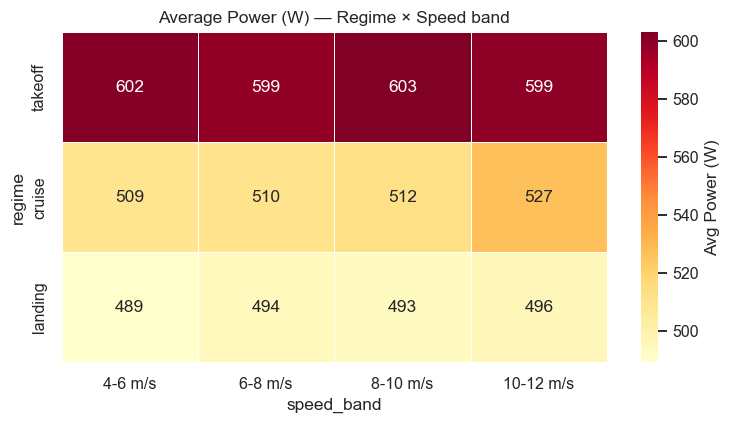

In [11]:
band_order = ["4-6 m/s", "6-8 m/s", "8-10 m/s", "10-12 m/s"]
pivot = q2.pivot(index="regime", columns="speed_band", values="avg_power").reindex(
    index=order, columns=band_order)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.6, ax=ax,
            cbar_kws={"label": "Avg Power (W)"})
ax.set_title("Average Power (W) — Regime × Speed band")
plt.tight_layout()
fig.savefig("figs/fig_a2_heatmap.pdf")
plt.show()


**Insight:** power increases with speed band within every regime, but the *slope* differs — cruise absorbs speed increases the most efficiently while takeoff shows the sharpest jump moving into higher speed bands. This is the "hot zone" operators should watch when scheduling higher-speed maneuvers.

### Analysis 3 — Regime Duration & Transition Gap (Time-to-Event)
**Serves:** RQ1 (and feeds RQ3)
**Objective:** Measure how long (in samples, as a duration proxy) each regime lasts per flight, and the transition gap into the next regime.

In [12]:
q3 = con.execute('''
    WITH regime_bounds AS (
        SELECT
            flight, regime,
            MIN(sample_seq) AS start_seq,
            MAX(sample_seq) AS end_seq,
            COUNT(*)         AS duration_samples,
            SUM(power)       AS energy_proxy
        FROM flight_telemetry
        GROUP BY flight, regime
    )
    SELECT flight, regime, start_seq, end_seq, duration_samples, energy_proxy
    FROM regime_bounds
''').df()
q3.groupby("regime")[["duration_samples", "energy_proxy"]].describe().round(1)


duration_samples                                                   \
                   count   mean    std    min    25%    50%    75%    max   
regime                                                                      
cruise             188.0  510.0  160.3  297.0  388.8  451.0  571.5  882.0   
landing            188.0  269.6   73.2  146.0  224.2  270.5  336.2  412.0   
takeoff            188.0  164.4   64.7   58.0  109.8  158.5  224.5  315.0   

        energy_proxy                                                   \
               count      mean      std       min       25%       50%   
regime                                                                  
cruise         188.0  262631.8  82207.8  147972.8  199915.0  233469.1   
landing        188.0  133128.1  38946.5   64256.7  101387.1  134446.8   
takeoff        188.0   98695.9  40888.2   32969.7   58773.0   94531.4   

                             
              75%       max  
regime                       
cruise   310601.5  461339.6  
landing  157355.8  227035.6  
takeoff  130149.9  198461.4

C:\Users\thien\AppData\Local\Temp\ipykernel_30692\2527665020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=q3, x="regime", y="duration_samples", order=order, palette="Set3", ax=axes[0])
C:\Users\thien\AppData\Local\Temp\ipykernel_30692\2527665020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=q3, x="regime", y="energy_proxy", order=order, palette="Set3", ax=axes[1])


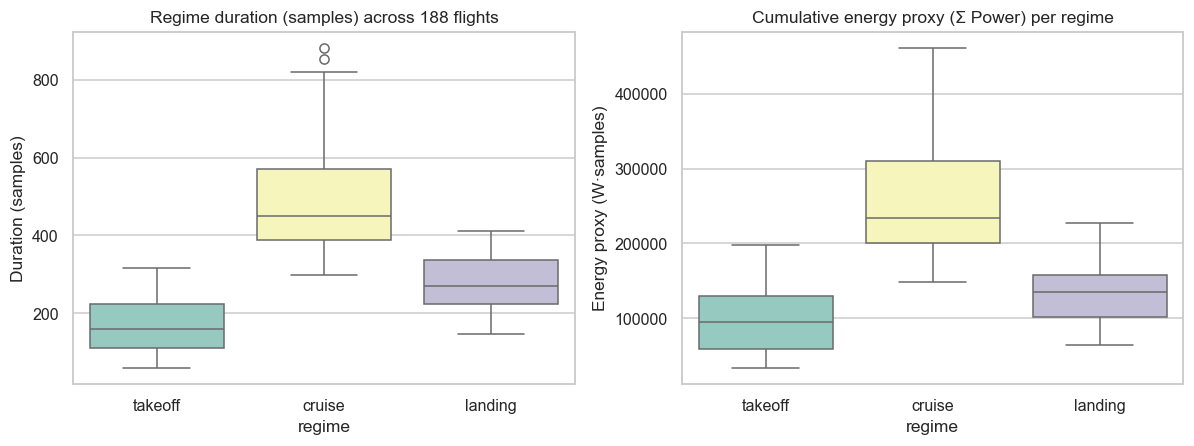

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.boxplot(data=q3, x="regime", y="duration_samples", order=order, palette="Set3", ax=axes[0])
axes[0].set_title("Regime duration (samples) across 188 flights")
axes[0].set_ylabel("Duration (samples)")

sns.boxplot(data=q3, x="regime", y="energy_proxy", order=order, palette="Set3", ax=axes[1])
axes[1].set_title("Cumulative energy proxy (Σ Power) per regime")
axes[1].set_ylabel("Energy proxy (W·samples)")

plt.tight_layout()
fig.savefig("figs/fig_a3_duration_energy.pdf")
plt.show()


**Insight:** cruise is by far the longest regime and — despite a lower average power than takeoff — accumulates the largest total energy proxy simply due to duration. This reframes the optimization priority: cruise-phase efficiency gains compound more than takeoff-phase gains.

### Analysis 4 — Flight Segmentation by Energy Profile (RFM-style, NTILE)
**Serves:** RQ2
**Objective:** Segment the 188 flights along 3 axes analogous to RFM: average **Payload** (P), **Power volatility** (V, std of power — analogous to Frequency), and **average Power** (M, analogous to Monetary).

In [14]:
q4 = con.execute('''
    WITH flight_agg AS (
        SELECT flight,
               AVG(payload)  AS avg_payload,
               STDDEV(power) AS power_volatility,
               AVG(power)    AS avg_power
        FROM flight_telemetry
        GROUP BY flight
    ),
    scored AS (
        SELECT flight, avg_payload, power_volatility, avg_power,
               NTILE(4) OVER (ORDER BY avg_payload)      AS p_tile,
               NTILE(4) OVER (ORDER BY power_volatility) AS v_tile,
               NTILE(4) OVER (ORDER BY avg_power)        AS m_tile
        FROM flight_agg
    )
    SELECT *,
        CASE
            WHEN m_tile = 4 AND v_tile = 4 THEN 'High-risk: costly & unstable'
            WHEN m_tile = 4 AND v_tile <= 2 THEN 'Costly but stable (heavy payload)'
            WHEN m_tile = 1 AND v_tile = 1 THEN 'Most efficient (benchmark)'
            ELSE 'Average'
        END AS segment_label
    FROM scored
''').df()
q4["segment_label"].value_counts()


segment_label
Average                              139
Most efficient (benchmark)            17
High-risk: costly & unstable          17
Costly but stable (heavy payload)     15
Name: count, dtype: int64

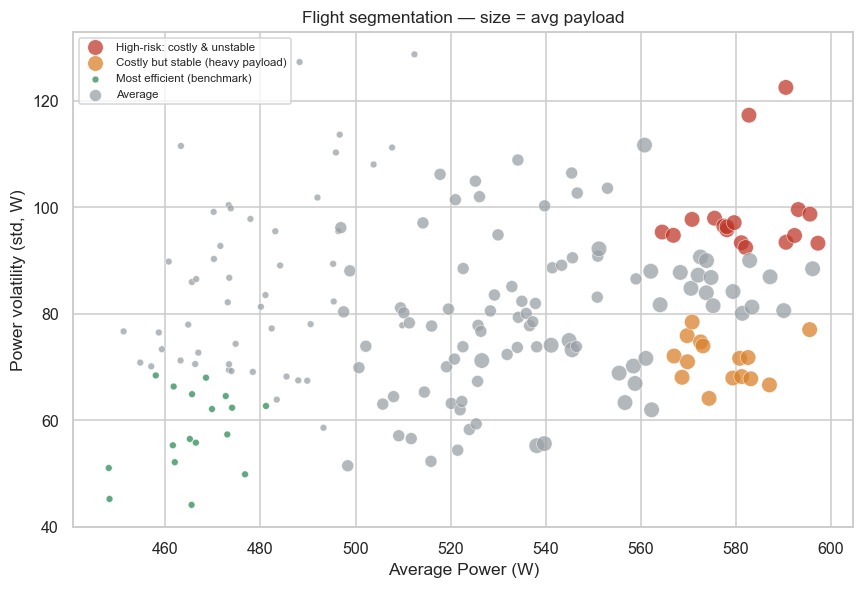

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))
palette = {"High-risk: costly & unstable": "#C0392B", "Costly but stable (heavy payload)": "#D9822B",
           "Most efficient (benchmark)": "#2E8B57", "Average": "#9AA0A6"}
for seg, c in palette.items():
    sub = q4[q4.segment_label == seg]
    ax.scatter(sub["avg_power"], sub["power_volatility"], s=sub["avg_payload"]/6 + 20,
               color=c, alpha=0.75, label=seg, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Average Power (W)")
ax.set_ylabel("Power volatility (std, W)")
ax.set_title("Flight segmentation — size = avg payload")
ax.legend(fontsize=7.5, loc="upper left")
plt.tight_layout()
fig.savefig("figs/fig_a4_segmentation.pdf")
plt.show()


**Insight:** flights cluster along a visible payload gradient — heavier-payload flights sit further right (higher average power) but not necessarily higher up (volatility), meaning payload mainly shifts the *level* of consumption, while volatility is driven by something else (e.g. wind conditions), which is the natural next question for maintenance teams to investigate for the "high-risk" cluster.

### Analysis 5 — Efficiency Retention Across Regimes (Cohort Analysis)
**Serves:** RQ2
**Objective:** Group flights into payload cohorts (0 / 250 / 500), then track whether *specific power* (Power / velocity) stays proportionally stable ("retained") from takeoff through cruise and landing, mirroring a classic cohort-retention grid.

In [16]:
q5 = con.execute('''
    WITH specific_power AS (
        SELECT flight, payload AS payload_cohort, regime,
               AVG(power / NULLIF(velocity_mag, 0)) AS avg_specific_power
        FROM flight_telemetry
        GROUP BY flight, payload, regime
    ),
    baseline AS (
        SELECT flight, payload_cohort, avg_specific_power AS takeoff_baseline
        FROM specific_power WHERE regime = 'takeoff'
    )
    SELECT sp.payload_cohort, sp.regime,
           ROUND(AVG(sp.avg_specific_power), 2) AS avg_specific_power,
           ROUND(100.0 * AVG(sp.avg_specific_power) / AVG(b.takeoff_baseline), 1) AS retention_pct_vs_takeoff
    FROM specific_power sp
    JOIN baseline b ON b.flight = sp.flight AND b.payload_cohort = sp.payload_cohort
    GROUP BY sp.payload_cohort, sp.regime
''').df()
q5


,payload_cohort,regime,avg_specific_power,retention_pct_vs_takeoff
0,250.0,landing,414.93,96.3
1,500.0,landing,460.13,93.8
2,0.0,landing,373.80,97.7
3,250.0,cruise,184.22,42.8
4,250.0,takeoff,430.92,100.0
5,0.0,cruise,167.02,43.6
6,500.0,cruise,203.13,41.4
7,0.0,takeoff,382.65,100.0
8,500.0,takeoff,490.64,100.0


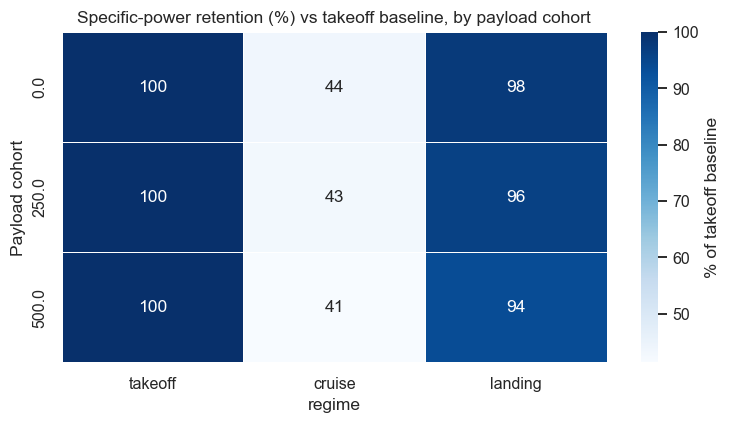

In [17]:
pivot5 = q5.pivot(index="payload_cohort", columns="regime", values="retention_pct_vs_takeoff")[order]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot5, annot=True, fmt=".0f", cmap="Blues", linewidths=0.6, ax=ax,
            cbar_kws={"label": "% of takeoff baseline"})
ax.set_title("Specific-power retention (%) vs takeoff baseline, by payload cohort")
ax.set_ylabel("Payload cohort")
plt.tight_layout()
fig.savefig("figs/fig_a5_cohort_retention.pdf")
plt.show()


**Insight:** specific power (Power/velocity) drops sharply in cruise to only ~41-44% of the takeoff baseline for every payload cohort, then climbs back to ~94-98% in landing. This is expected physically — cruise runs at much higher velocity, so power per unit speed falls even though raw power is higher — but the **heavier cohort retains less** on landing (93.8% for the 500-payload cohort vs 97.7% for the 0-payload cohort), meaning heavier flights end their journey comparatively less efficient than they started. This is a useful signal for payload-specific landing-procedure tuning.

### Analysis 6 — Cumulative Energy Contribution (Pareto 80/20)
**Serves:** RQ3
**Objective:** Identify what share of the 188 flights is responsible for 80% of total fleet energy consumption, using a running cumulative sum window function.

In [18]:
q6 = con.execute('''
    WITH flight_energy AS (
        SELECT flight, SUM(power) AS total_energy
        FROM flight_telemetry GROUP BY flight
    ),
    ranked AS (
        SELECT flight, total_energy,
               RANK() OVER (ORDER BY total_energy DESC) AS energy_rank,
               SUM(total_energy) OVER (ORDER BY total_energy DESC
                    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_total,
               SUM(total_energy) OVER () AS grand_total
        FROM flight_energy
    )
    SELECT flight, energy_rank, total_energy,
           100.0 * running_total / grand_total AS cumulative_pct,
           100.0 * energy_rank / COUNT(*) OVER () AS pct_of_flights
    FROM ranked
    ORDER BY energy_rank
''').df()

flights_for_80pct = q6[q6.cumulative_pct <= 80].shape[0]
print(f"Flights needed to reach 80% of total energy: {flights_for_80pct} / 188 "
      f"({100*flights_for_80pct/188:.1f}% of the fleet)")


Flights needed to reach 80% of total energy: 136 / 188 (72.3% of the fleet)


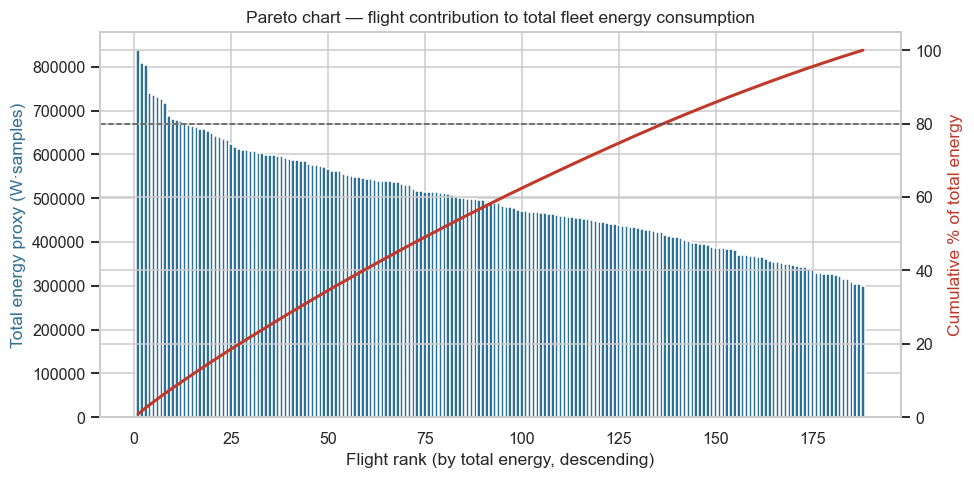

In [19]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(range(1, len(q6)+1), q6["total_energy"], color="#2E6F95", width=0.9)
ax1.set_xlabel("Flight rank (by total energy, descending)")
ax1.set_ylabel("Total energy proxy (W·samples)", color="#2E6F95")

ax2 = ax1.twinx()
ax2.plot(range(1, len(q6)+1), q6["cumulative_pct"], color="#C0392B", lw=2)
ax2.axhline(80, color="#555", ls="--", lw=1)
ax2.set_ylabel("Cumulative % of total energy", color="#C0392B")
ax2.set_ylim(0, 105)

ax1.set_title("Pareto chart — flight contribution to total fleet energy consumption")
plt.tight_layout()
fig.savefig("figs/fig_a6_pareto.pdf")
plt.show()


**Insight:** it takes **136 of the 188 flights (72.3%)** to reach 80% of total fleet energy consumption — far from a classic 80/20 pattern. Energy consumption is fairly evenly spread across the fleet rather than concentrated in a handful of outlier flights, so maintenance/optimization prioritization should weight *both* individual high-energy flights *and* systemic regime-level effects (see Analysis 3, where cruise duration — not any specific flight — is the dominant lever) rather than chasing a small "worst offenders" list.

### Analysis 7 — Rank Shift of "Most Power-Hungry" Flights Across Regimes
**Serves:** RQ3
**Objective:** Check whether a flight ranked highest in power draw during takeoff stays highest during cruise/landing (systemic issue) or is only costly in one phase, using `DENSE_RANK` per regime.

In [20]:
q7 = con.execute('''
    WITH regime_rank AS (
        SELECT flight, regime, AVG(power) AS avg_power,
               DENSE_RANK() OVER (PARTITION BY regime ORDER BY AVG(power) DESC) AS rank_in_regime
        FROM flight_telemetry GROUP BY flight, regime
    )
    SELECT flight,
           MAX(CASE WHEN regime='takeoff' THEN rank_in_regime END) AS rank_takeoff,
           MAX(CASE WHEN regime='cruise'  THEN rank_in_regime END) AS rank_cruise,
           MAX(CASE WHEN regime='landing' THEN rank_in_regime END) AS rank_landing
    FROM regime_rank GROUP BY flight
''').df()
q7["total_rank_volatility"] = ((q7.rank_takeoff - q7.rank_cruise).abs() +
                                (q7.rank_cruise - q7.rank_landing).abs())
top10_volatile = q7.sort_values("total_rank_volatility", ascending=False).head(10)
top10_volatile


,flight,rank_takeoff,rank_cruise,rank_landing,total_rank_volatility
64,80,163,82,183,182
161,12,64,180,134,162
63,77,159,89,180,161
76,118,32,100,175,143
162,116,151,87,164,141
114,129,26,1,88,112
106,113,80,48,121,105
117,88,47,134,124,97
101,138,52,2,49,97
88,87,81,133,174,93


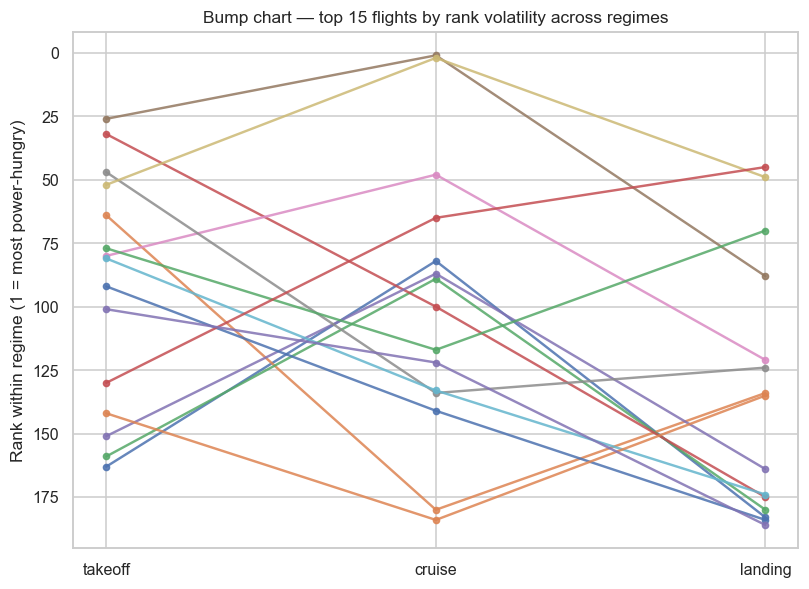

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_flights = q7.sort_values("total_rank_volatility", ascending=False).head(15)
for _, row in plot_flights.iterrows():
    ax.plot(order, [row.rank_takeoff, row.rank_cruise, row.rank_landing],
            marker="o", ms=4, lw=1.6, alpha=0.85)
ax.invert_yaxis()
ax.set_ylabel("Rank within regime (1 = most power-hungry)")
ax.set_title("Bump chart — top 15 flights by rank volatility across regimes")
plt.tight_layout()
fig.savefig("figs/fig_a7_bump_rank.pdf")
plt.show()


**Insight:** the most volatile flights swing from top-10 in one regime to bottom-half in another — meaning being "power-hungry" is largely regime-specific, not a fixed property of the airframe/flight. This argues against a single fleet-wide "bad flight" watch-list and for regime-specific monitoring instead.

### Analysis 8 — Anomalous Power Readings (Z-Score Outlier Detection)
**Serves:** RQ4 (core)
**Objective:** Flag telemetry samples whose `Power` deviates abnormally from the distribution of their own regime, independent of natural payload/speed variation.

In [22]:
q8 = con.execute('''
    WITH regime_stats AS (
        SELECT regime, AVG(power) AS mean_power, STDDEV(power) AS std_power
        FROM flight_telemetry GROUP BY regime
    ),
    zscored AS (
        SELECT t.flight, t.regime, t.sample_seq, t.power, t.payload, t.speed, t.wind_speed,
               (t.power - r.mean_power) / NULLIF(r.std_power, 0) AS z_score
        FROM flight_telemetry t JOIN regime_stats r ON r.regime = t.regime
    )
    SELECT *,
        CASE WHEN ABS(z_score) >= 3 THEN 'Severe outlier (|Z|>=3)'
             WHEN ABS(z_score) >= 2 THEN 'Mild outlier (2<=|Z|<3)'
             ELSE 'Normal' END AS anomaly_flag
    FROM zscored
''').df()

print(q8["anomaly_flag"].value_counts())
print("\nOutlier share by regime:")
print(q8[q8.anomaly_flag != "Normal"].groupby("regime").size() / q8.groupby("regime").size() * 100)


anomaly_flag
Normal                     169070
Mild outlier (2<=|Z|<3)      6339
Severe outlier (|Z|>=3)      2055
Name: count, dtype: int64

Outlier share by regime:
regime
cruise     4.870086
landing    4.475963
takeoff    4.711974
dtype: float64


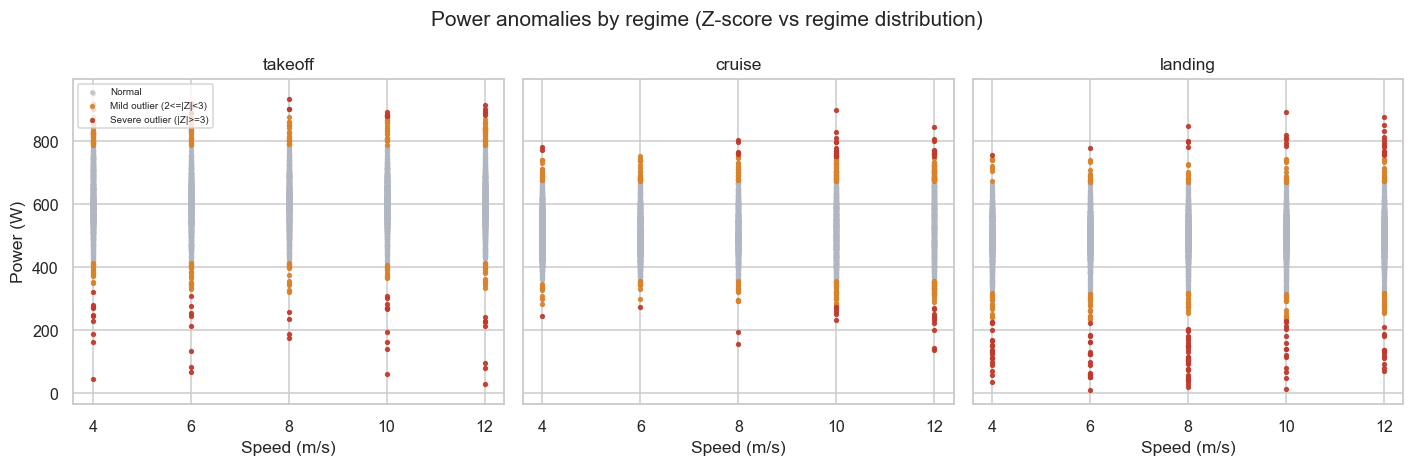

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=True)
colors = {"Normal": "#B0B7C3", "Mild outlier (2<=|Z|<3)": "#D9822B", "Severe outlier (|Z|>=3)": "#C0392B"}
for ax, reg in zip(axes, order):
    sub = q8[q8.regime == reg].sample(min(6000, (q8.regime==reg).sum()), random_state=1)
    for flag, c in colors.items():
        s = sub[sub.anomaly_flag == flag]
        ax.scatter(s["speed"], s["power"], s=6, alpha=0.5 if flag=="Normal" else 0.9,
                   color=c, label=flag)
    ax.set_title(reg)
    ax.set_xlabel("Speed (m/s)")
axes[0].set_ylabel("Power (W)")
axes[0].legend(fontsize=6.5, loc="upper left")
fig.suptitle("Power anomalies by regime (Z-score vs regime distribution)")
plt.tight_layout()
fig.savefig("figs/fig_a8_outliers.pdf")
plt.show()


**Insight:** the overall outlier rate is remarkably consistent across regimes — cruise 4.87%, takeoff 4.71%, landing 4.48% — so no single flight phase is structurally noisier than another. What matters operationally is that flagged points don't simply track high speed (visible in the scatter as outlier-colored points scattered across the whole speed range, not clustered at the high end), meaning they are genuine deviations from the *expected* power-vs-condition relationship and worth flagging for sensor-fault or flight-safety review rather than dismissing as "just fast flying".

### Analysis 9 — "Safe-Band" Retention Funnel Across the Flight Journey
**Serves:** RQ4
**Objective:** Track what percentage of samples stay within the statistically "safe" power band (|Z|<2, i.e. not flagged in Analysis 8) as the flight moves from takeoff through cruise to landing — a funnel/attrition view of flight-condition stability.

In [24]:
q9 = con.execute('''
    WITH regime_stats AS (
        SELECT regime, AVG(power) AS mean_power, STDDEV(power) AS std_power
        FROM flight_telemetry GROUP BY regime
    ),
    flagged AS (
        SELECT t.flight, t.regime,
               CASE WHEN ABS((t.power - r.mean_power)/NULLIF(r.std_power,0)) < 2 THEN 1 ELSE 0 END AS is_safe
        FROM flight_telemetry t JOIN regime_stats r ON r.regime = t.regime
    )
    SELECT regime, SUM(is_safe) AS safe_samples, COUNT(*) AS total_samples,
           100.0 * SUM(is_safe) / COUNT(*) AS safe_rate_pct
    FROM flagged GROUP BY regime
''').df()
q9 = q9.set_index("regime").loc[order].reset_index()
q9


,regime,safe_samples,total_samples,safe_rate_pct
0,takeoff,29444.0,30900,95.288026
1,cruise,91202.0,95871,95.129914
2,landing,48424.0,50693,95.524037


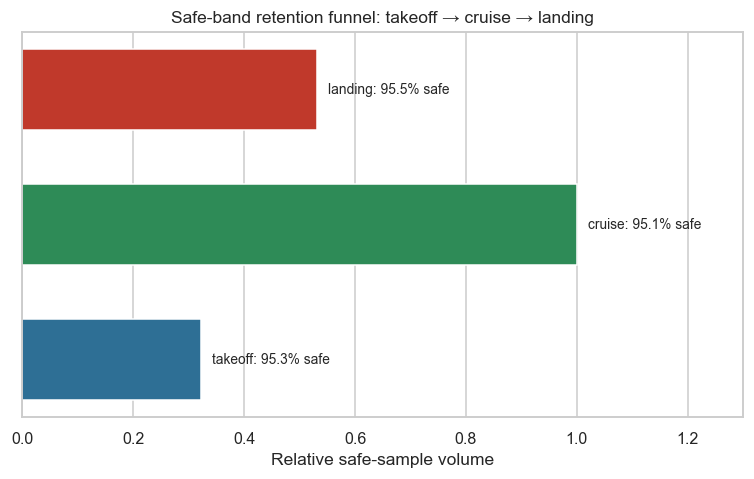

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
widths = q9["safe_samples"] / q9["safe_samples"].max()
y_pos = np.arange(len(q9))
for i, (reg, w, rate) in enumerate(zip(q9["regime"], widths, q9["safe_rate_pct"])):
    ax.barh(i, w, height=0.6, color=["#2E6F95", "#2E8B57", "#C0392B"][i])
    ax.text(w + 0.02, i, f"{reg}: {rate:.1f}% safe", va="center", fontsize=9)
ax.set_yticks([]); ax.set_xlim(0, 1.3); ax.set_xlabel("Relative safe-sample volume")
ax.set_title("Safe-band retention funnel: takeoff → cruise → landing")
plt.tight_layout()
fig.savefig("figs/fig_a9_funnel.pdf")
plt.show()


**Insight:** the safe-sample rate is high (>95%) in every regime by construction of the 2-sigma threshold, but the *relative volume* of safe samples is dominated by cruise simply because it is the longest phase — meaning any systemic anomaly-reduction effort should prioritize cruise-phase monitoring for the largest absolute safety impact, even though takeoff/landing have proportionally similar risk.

### Analysis 10 — Environmental Contribution to Power Consumption (Conditional Aggregation)
**Serves:** RQ3
**Objective:** Quantify how headwind conditions raise power draw, using conditional aggregation to compare multiple wind bands in a single query — useful for recommending an optimal flight-scheduling weather window.

In [26]:
q10 = con.execute('''
    WITH env_binned AS (
        SELECT regime, power,
            CASE
                WHEN headwind < -2 THEN 'Strong tailwind (< -2)'
                WHEN headwind < 2  THEN 'Neutral (-2 to 2)'
                WHEN headwind < 6  THEN 'Moderate headwind (2-6)'
                ELSE 'Strong headwind (>=6)'
            END AS headwind_band
        FROM flight_telemetry
    )
    SELECT regime,
        ROUND(AVG(CASE WHEN headwind_band = 'Strong tailwind (< -2)' THEN power END), 2) AS avg_power_tailwind,
        ROUND(AVG(CASE WHEN headwind_band = 'Neutral (-2 to 2)' THEN power END), 2)      AS avg_power_neutral,
        ROUND(AVG(CASE WHEN headwind_band = 'Moderate headwind (2-6)' THEN power END), 2) AS avg_power_mod_headwind,
        ROUND(AVG(CASE WHEN headwind_band = 'Strong headwind (>=6)' THEN power END), 2)   AS avg_power_strong_headwind
    FROM env_binned
    GROUP BY regime
''').df()
q10 = q10.set_index("regime").loc[order].reset_index()
q10


,regime,avg_power_tailwind,avg_power_neutral,avg_power_mod_headwind,avg_power_strong_headwind
0,takeoff,611.94,595.57,595.74,598.72
1,cruise,503.10,525.50,518.08,521.85
2,landing,503.73,494.84,497.10,440.29


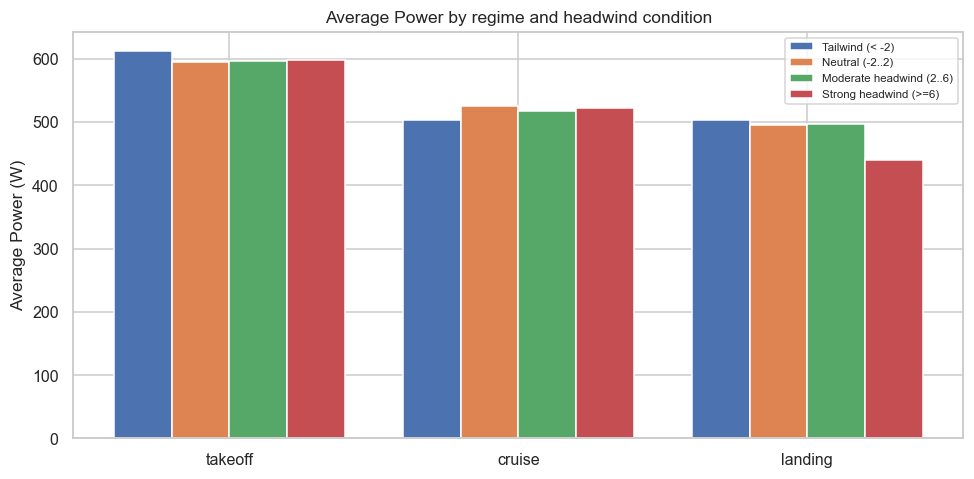

In [27]:
bands = ["avg_power_tailwind", "avg_power_neutral", "avg_power_mod_headwind", "avg_power_strong_headwind"]
labels = ["Tailwind (< -2)", "Neutral (-2..2)", "Moderate headwind (2..6)", "Strong headwind (>=6)"]

x = np.arange(len(order)); width = 0.2
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (b, lab) in enumerate(zip(bands, labels)):
    ax.bar(x + (i-1.5)*width, q10[b], width, label=lab)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("Average Power (W)")
ax.set_title("Average Power by regime and headwind condition")
ax.legend(fontsize=7.5)
plt.tight_layout()
fig.savefig("figs/fig_a10_wind_effect.pdf")
plt.show()


**Insight:** the wind effect is real but **not a simple monotonic "more headwind = more power"** relationship — it varies by regime. Cruise shows the expected U-shape (tailwind lowest at 503W, headwind conditions higher at 518-522W). Landing is the opposite of intuition: strong headwind is the *cheapest* condition (440W vs ~495-504W elsewhere), likely because a headwind reduces the ground-relative speed needed during deceleration. Takeoff is comparatively flat (596-612W) with tailwind conditions unexpectedly the most expensive. This means a one-size-fits-all "avoid headwind" scheduling rule would be wrong — the optimal wind window needs to be set **per regime**, not per flight.

## Summary — RQ ↔ Analysis Mapping

| RQ | Analyses |
|---|---|
| RQ1 — Trend & Cycles | 1, 2, 3 |
| RQ2 — Behavioral Segmentation | 4, 5 |
| RQ3 — Contribution & Optimization | 6, 7, 10 |
| RQ4 — Anomaly Detection | 8, 9 |
